# SMS Spam Classifier
## Exploratory Data Analysis (EDA)
**Author:** Thusyya Vardhan  
**Dataset:** SMS Spam Collection (UCI ML Repository)  
**Goal:** Understand the dataset, find patterns between spam and ham messages

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## 2. Loading the Dataset

In [5]:
df = pd.read_csv('../data/spam.csv',encoding = 'latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df = df[["v1","v2"]]
df.columns = ["label","message"]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.shape

(5572, 2)

## 3. Data Cleaning

In [11]:
print(df.isnull().sum())
print(f"Duplicates : {df.duplicated().sum()}")

label      0
message    0
dtype: int64
Duplicates : 403


In [13]:
df = df.drop_duplicates()
df.shape

(5169, 2)

## 4. Class Distribution

Checking the balance between ham and spam messages.
Note: If the dataset is imbalanced, accuracy alone will be a misleading metric.

In [14]:
print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


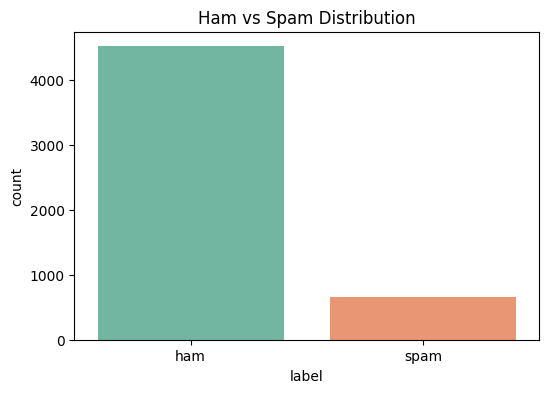

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label', palette='Set2', legend=False)
plt.title('Ham vs Spam Distribution')
plt.savefig('../data/class_dist.png', dpi=150)
plt.show()

## 5. Message Length Analysis

Analyzing whether spam messages tend to be longer than ham messages.
This could be a useful feature for the model later.

In [17]:
df['length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print(df.groupby('label')[['length', 'word_count']].mean())

           length  word_count
label                        
ham     70.459256   14.134632
spam   137.891271   23.681470


In [18]:
df.head()

,label,message,length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


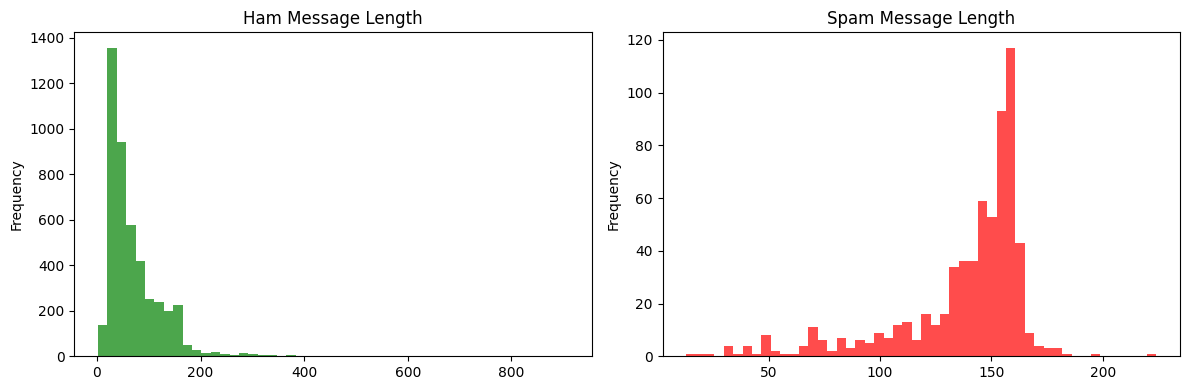

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['label']=='ham']['length'].plot(kind='hist', bins=50, ax=axes[0],
                                       color='green', alpha=0.7, title='Ham Message Length')
df[df['label']=='spam']['length'].plot(kind='hist', bins=50, ax=axes[1],
                                        color='red', alpha=0.7, title='Spam Message Length')
plt.tight_layout()
plt.show()

## 6. Wordcloud Analysis

Visualizing the most frequently occurring words in ham and spam messages.

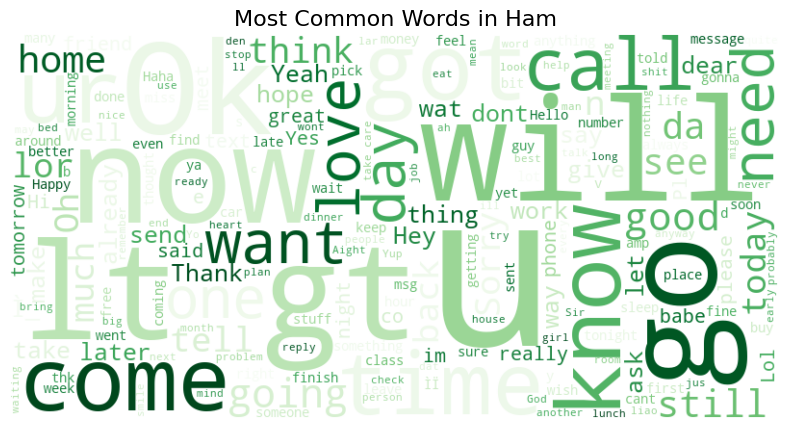

In [20]:
ham_text = ' '.join(df[df['label'] == 'ham']['message'])

wordcloud = WordCloud(width=800, height=400, 
                       background_color='white',
                       colormap='Greens').generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Ham', fontsize=16)
plt.savefig('../data/ham_wordcloud.png', dpi=150)
plt.show()

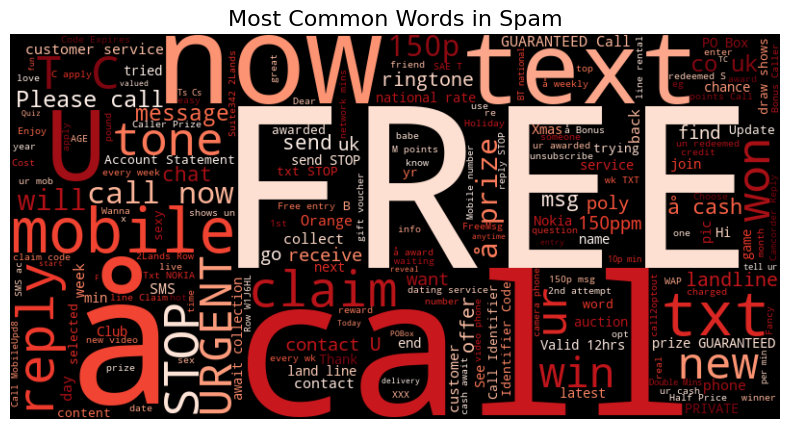

In [21]:
spam_text = ' '.join(df[df['label'] == 'spam']['message'])

wordcloud = WordCloud(width=800, height=400, 
                       background_color='black',
                       colormap='Reds').generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam', fontsize=16)
plt.savefig('../data/spam_wordcloud.png', dpi=150)
plt.show()

### Key Observation
- Ham messages contain conversational words like *"ok", "will", "now", "got"*
- Spam messages are dominated by words like *"free", "call", "won", "claim", "prize"*
- These distinctive word patterns are what our ML model will learn to detect
- This also confirms that **TF-IDF vectorization** will be effective for this problem

## 7. Saving Cleaned Data

In [22]:
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.to_csv('../data/spam_clean.csv', index=False)
print(df.head())
print("✅ Cleaned data saved!")

  label                                            message  length  \
0   ham  Go until jurong point, crazy.. Available only ...     111   
1   ham                      Ok lar... Joking wif u oni...      29   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155   
3   ham  U dun say so early hor... U c already then say...      49   
4   ham  Nah I don't think he goes to usf, he lives aro...      61   

   word_count  label_enc  
0          20          0  
1           6          0  
2          28          1  
3          11          0  
4          13          0  
✅ Cleaned data saved!


In [23]:
df.head()

,label,message,length,word_count,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,0
1,ham,Ok lar... Joking wif u oni...,29,6,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,1
3,ham,U dun say so early hor... U c already then say...,49,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,0
